# Phase 5 - Dense Semantic-Retrieval Baseline

Dense retriever (`BAAI/bge-small-en-v1.5`, FAISS `IndexFlatIP` = exact cosine) over the
**same** `chunks_n200.parquet` BM25 indexed, scored on the **same** frozen golden set
(hash asserted below), using the **same** `evaluate_retriever` harness from Phase 4.
Any difference vs BM25 is the *retriever*, not the corpus, eval set, or metric code.

**Pre-registered hypothesis (from Phase 4):** if EDGAR's lexical deficit is caused by
boilerplate near-duplication, dense should help EDGAR *more* than earnings, **narrowing
the EDGAR-earnings gap** relative to BM25. Watch `section_1A` (BM25's worst, MRR@10 = 0.35).

**Execution order is deliberate:** (1) assert golden hash → (2) embed corpus [cached] →
(3) retrieve → (4) metrics → (5) breakdowns → (6) figures. Figures are built only after
numbers exist.

### 0. Environment
First run only — install deps via uv, then restart the kernel.

In [ ]:
# Run once in a terminal, then restart the kernel:
#   uv add sentence-transformers faiss-cpu
# If faiss-cpu has no wheel for your Python/OS, the retriever auto-falls back to an
# exact NumPy matmul (identical results at this corpus size) — no action needed.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time, json, platform
from pathlib import Path
import numpy as np
import pandas as pd

sys.path.insert(0, "../src/retrieval")
import dense_retriever as dr
from dense_retriever import DenseRetriever, load_chunks, DEFAULT_MODEL, DEFAULT_QUERY_PREFIX
from golden_dataset_builder import load_golden_set, hash_golden_set
from bm25_retriever import evaluate_retriever

np.random.seed(42)
pd.set_option("display.width", 120)
print("python", platform.python_version(), "| pandas", pd.__version__, "| numpy", np.__version__)

python 3.13.0 | pandas 3.0.2 | numpy 2.4.4


### 1. Config
Single place to switch the model or point at a larger corpus for the optional n=200/300/500 etc
robustness run. The golden set is **never** changed (reuse contract); only `CHUNKS_PATH`
moves. The embedding cache keys on model + chunk config + chunk-id fingerprint, so n=100
and n=300 caches never collide.

In [2]:
DATA = Path("../data/processed")
FIGS = Path("../reports/figures"); FIGS.mkdir(parents=True, exist_ok=True)
NOTES = Path("../notes"); NOTES.mkdir(parents=True, exist_ok=True)
CACHE_DIR = "../data/embeddings"

CHUNKS_PATH = DATA / "chunks_n200.parquet"      # n=100 corpus (21,050 chunks). Swap for n=300 run.
GOLDEN_PATH = DATA / "golden_queries.parquet"   # frozen; reused unchanged at every scale
EXPECTED_HASH = "325634f065147a49d6fba6e0fb021107d536b1aa717bcbbb4a10b68b93c0e72e"

MODEL_NAME = DEFAULT_MODEL   # BAAI/bge-small-en-v1.5
K_VALUES = (1, 3, 5, 10)
print("model:", MODEL_NAME, "| query prefix:", repr(DEFAULT_QUERY_PREFIX))

model: BAAI/bge-small-en-v1.5 | query prefix: 'Represent this sentence for searching relevant passages: '


### 2. Load golden set + ASSERT hash (the gate)
Halts before embedding if the eval set is not byte-identical to Phase 4's. This is the
proof, reproducible in the viva, that BM25 / dense / hybrid were scored on one set.

In [3]:
golden = load_golden_set(GOLDEN_PATH)
actual_hash = hash_golden_set(golden)
assert actual_hash == EXPECTED_HASH, (
    f"GOLDEN SET MISMATCH\n expected {EXPECTED_HASH}\n got      {actual_hash}\n"
    "Refusing to proceed — Phase 5 must score the Phase-4 set unchanged.")
print(f"golden hash OK ({actual_hash[:8]}…) | {len(golden)} queries")
print(golden["source"].value_counts().to_dict())

golden hash OK (325634f0…) | 60 queries
{'earnings': 30, 'edgar': 30}


### 3. Load the shared chunk corpus
The identical file BM25 indexed.

In [4]:
chunks = load_chunks(CHUNKS_PATH)
print(f"{len(chunks):,} chunks | sources:", chunks["source"].value_counts().to_dict())
chunks[["chunk_id", "source", "subtype", "char_length"]].head(3)

21,050 chunks | sources: {'edgar': 16967, 'earnings': 4083}


,chunk_id,source,subtype,char_length
0,edgar_0000_section_1_chunk_000,edgar,section_1,1464
1,edgar_0000_section_1_chunk_001,edgar,section_1,1462
2,edgar_0000_section_1_chunk_002,edgar,section_1,1495


### 4. Build the dense retriever (embed corpus, timed + cached)
First run embeds the corpus on CPU (~2–5 min for 21k chunks with bge-small) and writes the
cache; re-runs load it in seconds. The query prefix is applied to **queries only**.

In [5]:
t0 = time.time()
retriever = DenseRetriever.from_model(
    chunks, model_name=MODEL_NAME, cache_dir=CACHE_DIR, use_cache=True,
)
build_seconds = time.time() - t0
print(f"build (embed+index): {build_seconds:.2f}s | backend: {retriever.backend} "
      f"| dim: {retriever.dim} | n: {len(retriever):,}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

d:\General IT\AI-ML-LJMU\final_thesis\code\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\anshu\.cache\huggingface\hub\models--BAAI--bge-small-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

build (embed+index): 1974.30s | backend: faiss | dim: 384 | n: 21,050


### 4a. Sanity check - eyeball one retrieval
Confirm the top hit is on-topic before trusting the metrics.

In [6]:
demo = golden.iloc[0]
print("QUERY:", demo["query_text"])
print("GOLD :", demo["relevant_chunk_ids"])
for h in retriever.retrieve(demo["query_text"], k=3):
    print(f"  rank {h['rank']} | {h['score']:.3f} | {h['chunk_id']} | {h['text'][:90]}…")

QUERY: In the closing remarks of the call, what did the CEO thank participants for and say about the company's future?
GOLD : ['earnings_0000_qa_chunk_030']
  rank 1 | 0.721 | earnings_0064_full_chunk_029 | Praful Mehta : Got it. Thanks so much, guys. Very helpful. Curt Morgan : Thank you. Operat…
  rank 2 | 0.717 | earnings_0018_full_chunk_034 | Operator : Thank you for your question. I will now turn the conference back over to George…
  rank 3 | 0.714 | earnings_0088_qa_chunk_029 | Operator : Ladies and gentlemen, this concludes our question-and-answer session. I would l…


### 5. Score every golden query (reuse the Phase-4 harness, unchanged)

In [7]:
per_q = evaluate_retriever(retriever, golden, k_values=K_VALUES)
print("per-query rows:", len(per_q))
per_q.head(3)

per-query rows: 60


,query_id,source,subtype,n_relevant,precision@1,recall@1,mrr@1,precision@3,recall@3,mrr@3,precision@5,recall@5,mrr@5,precision@10,recall@10,mrr@10
0,q000,earnings,qa,1,0.0,0.0,0.0,0.000000,0.0,0.000000,0.2,1.0,0.250000,0.1,1.0,0.250000
1,q001,earnings,qa,1,0.0,0.0,0.0,0.333333,1.0,0.333333,0.2,1.0,0.333333,0.1,1.0,0.333333
2,q002,earnings,full,1,1.0,1.0,1.0,0.333333,1.0,1.000000,0.2,1.0,1.000000,0.1,1.0,1.000000


### 6. Aggregate metrics
`pandas 3.0` — no `groupby.apply`; plain `.mean()` and `groupby(col)[cols].mean()`.

In [8]:
metric_cols = [f"{m}@{k}" for k in K_VALUES for m in ("precision", "recall", "mrr")]

overall = per_q[metric_cols].mean()
overall_tbl = pd.DataFrame({
    "Precision@K": [overall[f"precision@{k}"] for k in K_VALUES],
    "Recall@K":    [overall[f"recall@{k}"] for k in K_VALUES],
    "MRR@K":       [overall[f"mrr@{k}"] for k in K_VALUES],
}, index=[f"K={k}" for k in K_VALUES]).round(4)
overall_tbl

,Precision@K,Recall@K,MRR@K
K=1,0.4667,0.4667,0.4667
K=3,0.2000,0.6000,0.5250
K=5,0.1333,0.6667,0.5400
K=10,0.0733,0.7333,0.5504


#### 6a. Formal vs conversational (primary breakdown)

In [9]:
by_source = per_q.groupby("source")[metric_cols].mean().round(4)
by_source[[f"recall@{k}" for k in (1,5,10)] + [f"mrr@{k}" for k in (5,10)]]

,recall@1,recall@5,recall@10,mrr@5,mrr@10
source,,,,,
earnings,0.5667,0.8000,0.8333,0.6356,0.6411
edgar,0.3667,0.5333,0.6333,0.4444,0.4597


#### 6b. Per-subtype (exploratory only, n = 6–12 per cell)

In [10]:
by_subtype = per_q.groupby("subtype")[metric_cols].mean().round(4)
counts = per_q["subtype"].value_counts()
by_subtype = by_subtype.assign(n=counts).sort_values("mrr@10", ascending=False)
by_subtype[["mrr@10", "recall@10", "n"]]

,mrr@10,recall@10,n
subtype,,,
full,0.8636,0.9091,11
section_1,0.6667,0.8333,6
prepared_remarks,0.5714,0.5714,7
section_7,0.5000,0.5000,6
qa,0.4778,0.9167,12
section_1A,0.4292,0.8000,10
section_8,0.3125,0.3750,8


### 7. Hypothesis test — does dense narrow the EDGAR–earnings gap?
Compare the gap (earnings − EDGAR) for **dense** against **BM25** (loaded from
`phase_04_summary.json`). A smaller positive gap → dense disproportionately helps EDGAR,
confirming the pre-registered prediction.

In [11]:
# Load BM25 numbers for a like-for-like comparison.
bm25_summary = None
for cand in [NOTES / "phase_04_summary.json", DATA.parent / "phase_04_summary.json",
             Path("../phase_04_summary.json")]:
    if cand.exists():
        bm25_summary = json.loads(cand.read_text()); break
assert bm25_summary is not None, "phase_04_summary.json not found - point the path at it."

def gap(metrics_by_source, metric):
    return metrics_by_source["earnings"][metric] - metrics_by_source["edgar"][metric]

dense_by_source = {s: by_source.loc[s].to_dict() for s in by_source.index}
rows = []
for metric in ("recall@1", "recall@5", "mrr@5", "mrr@10", "recall@10"):
    bm = bm25_summary["metrics_by_source"]
    rows.append({
        "metric": metric,
        "BM25_earnings": round(bm["earnings"][metric], 4),
        "BM25_edgar":    round(bm["edgar"][metric], 4),
        "BM25_gap":      round(gap(bm, metric), 4),
        "Dense_earnings": round(dense_by_source["earnings"][metric], 4),
        "Dense_edgar":    round(dense_by_source["edgar"][metric], 4),
        "Dense_gap":      round(gap(dense_by_source, metric), 4),
        "gap_narrowed":   round(gap(dense_by_source, metric) - gap(bm, metric), 4),
    })
gap_tbl = pd.DataFrame(rows)
print("Negative 'gap_narrowed' (esp. on MRR) = dense closed the gap → hypothesis supported.")
gap_tbl

Negative 'gap_narrowed' (esp. on MRR) = dense closed the gap → hypothesis supported.


,metric,BM25_earnings,BM25_edgar,BM25_gap,Dense_earnings,Dense_edgar,Dense_gap,gap_narrowed
0,recall@1,0.7000,0.4333,0.2667,0.5667,0.3667,0.2000,-0.0667
1,recall@5,0.8333,0.7333,0.1000,0.8000,0.5333,0.2667,0.1667
2,mrr@5,0.7411,0.5483,0.1928,0.6356,0.4444,0.1912,-0.0016
3,mrr@10,0.7537,0.5620,0.1917,0.6411,0.4597,0.1814,-0.0103
4,recall@10,0.9333,0.8333,0.1000,0.8333,0.6333,0.2000,0.1000


#### 7a. section_1A watch — did dense rescue BM25's worst subtype (MRR@10 = 0.35)?

In [12]:
if "section_1A" in by_subtype.index:
    s1a = by_subtype.loc["section_1A"]
    print(f"section_1A dense MRR@10 = {s1a['mrr@10']:.3f} (BM25 was 0.35) | n = {int(s1a['n'])}")
else:
    print("section_1A not present in this run's subtype breakdown.")

section_1A dense MRR@10 = 0.429 (BM25 was 0.35) | n = 10


### 8. Figures (built only now that numbers exist) → `reports/figures/phase05_*`

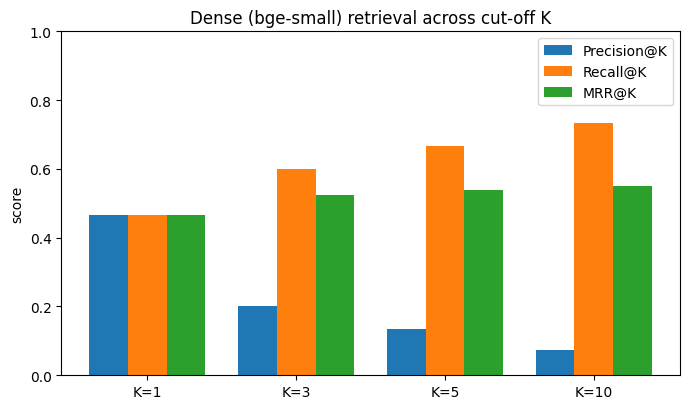

In [13]:
import matplotlib.pyplot as plt

# Fig 8: overall metrics by K
fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(K_VALUES)); w = 0.26
ax.bar(x - w, [overall[f"precision@{k}"] for k in K_VALUES], w, label="Precision@K")
ax.bar(x,     [overall[f"recall@{k}"] for k in K_VALUES],    w, label="Recall@K")
ax.bar(x + w, [overall[f"mrr@{k}"] for k in K_VALUES],       w, label="MRR@K")
ax.set_xticks(x); ax.set_xticklabels([f"K={k}" for k in K_VALUES])
ax.set_ylim(0, 1); ax.set_ylabel("score")
ax.set_title("Dense (bge-small) retrieval across cut-off K")
ax.legend(); fig.tight_layout()
fig.savefig(FIGS / "phase05_metrics_by_k.png", dpi=150); plt.show()

Figure 8. Dense (bge-small) retrieval performance across cut-off K (overall). phase05_metrics_by_k.png. Grouped bars show Precision@K, Recall@K and MRR@K at K = 1/3/5/10 over all 60 golden queries. Recall rises from 0.47 at K=1 to 0.73 at K=10 while MRR plateaus near 0.55, and Precision declines toward its 1/K single-positive ceiling. The dense baseline is competent but sits below the BM25 baseline (Recall@10 0.73 vs 0.88), establishing that a general-purpose small dense encoder does not by itself outperform exact lexical matching on this known-item financial retrieval task.

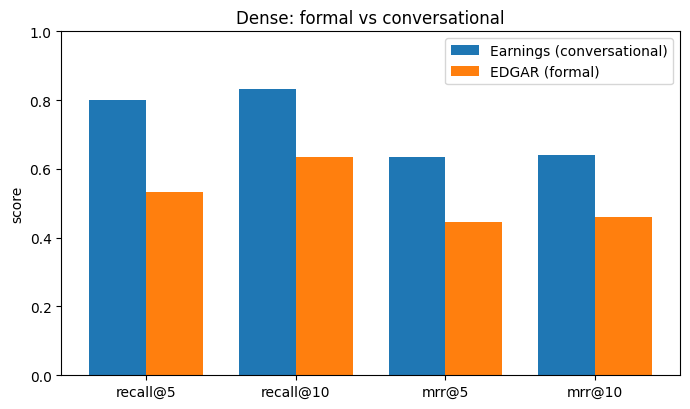

In [14]:
# Fig 9: EDGAR vs earnings (the core contrast)
fig, ax = plt.subplots(figsize=(7, 4.2))
metrics = ["recall@5", "recall@10", "mrr@5", "mrr@10"]
x = np.arange(len(metrics)); w = 0.38
ax.bar(x - w/2, [by_source.loc["earnings", m] for m in metrics], w, label="Earnings (conversational)")
ax.bar(x + w/2, [by_source.loc["edgar", m] for m in metrics],    w, label="EDGAR (formal)")
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylim(0, 1); ax.set_ylabel("score")
ax.set_title("Dense: formal vs conversational")
ax.legend(); fig.tight_layout()
fig.savefig(FIGS / "phase05_edgar_vs_earnings.png", dpi=150); plt.show()

Figure 9. Dense retrieval on formal vs conversational narratives. phase05_edgar_vs_earnings.png. Recall@5/10 and MRR@5/10 for EDGAR (formal 10-K sections) versus earnings (conversational calls). Earnings leads on every metric (MRR@10 0.64 vs 0.46), the same direction observed under BM25. Dense therefore neither reverses nor closes the formal-versus-conversational gap; the conversational advantage persists under semantic retrieval, indicating the gap is not merely an artefact of lexical near-duplication.

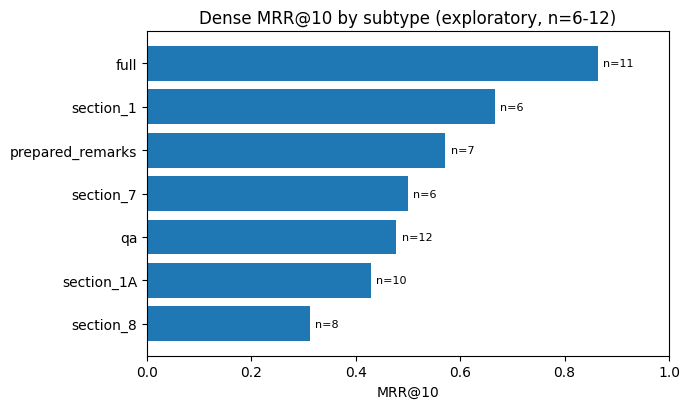

In [15]:
# Fig 10: MRR@10 by subtype (exploratory)
sub = by_subtype.sort_values("mrr@10")
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(sub.index, sub["mrr@10"])
for i, (v, n) in enumerate(zip(sub["mrr@10"], sub["n"])):
    ax.text(v + 0.01, i, f"n={int(n)}", va="center", fontsize=8)
ax.set_xlim(0, 1); ax.set_xlabel("MRR@10")
ax.set_title("Dense MRR@10 by subtype (exploratory, n=6-12)")
fig.tight_layout(); fig.savefig(FIGS / "phase05_mrr_by_subtype.png", dpi=150); plt.show()

Figure 10. Dense MRR@10 by document subtype (exploratory). phase05_mrr_by_subtype.png. Per-subtype mean MRR@10 with query counts annotated (n = 6–12, indicative only). Conversational full calls rank highest (0.86) and section_8 lowest (0.31). Risk Factors (section_1A) improves modestly under dense (0.43 vs 0.35 under BM25) - the one subtype moving in the direction the disambiguation hypothesis predicted - though the small n warrants caution.

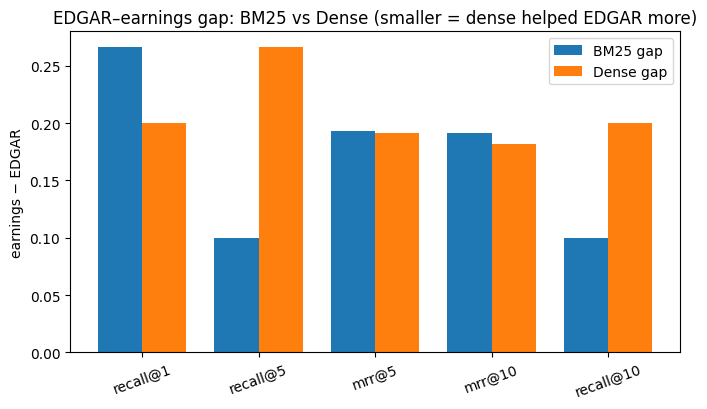

In [16]:
# Fig 11: BM25 vs Dense — the EDGAR–earnings gap (the hypothesis figure)
fig, ax = plt.subplots(figsize=(7, 4.2))
gm = gap_tbl.set_index("metric")
x = np.arange(len(gm)); w = 0.38
ax.bar(x - w/2, gm["BM25_gap"], w, label="BM25 gap")
ax.bar(x + w/2, gm["Dense_gap"], w, label="Dense gap")
ax.axhline(0, color="k", lw=0.6)
ax.set_xticks(x); ax.set_xticklabels(gm.index, rotation=20); ax.set_ylabel("earnings − EDGAR")
ax.set_title("EDGAR–earnings gap: BM25 vs Dense (smaller = dense helped EDGAR more)")
ax.legend(); fig.tight_layout()
fig.savefig(FIGS / "phase05_gap_bm25_vs_dense.png", dpi=150); plt.show()

Figure 11. EDGAR–earnings gap: BM25 versus dense. phase05_gap_bm25_vs_dense.png. The earnings−EDGAR performance gap under each retriever. On the primary ranking metrics (MRR@5/10) the gap is essentially unchanged (≈0.19 under both retrievers); on Recall@5/10 it widens under dense. Critically, the gap does not close because EDGAR improves - EDGAR scores fall on every metric under dense - so the pre-registered hypothesis that dense disproportionately benefits formal filings is not supported.

### 9. Write machine-readable summary → `notes/phase_05_summary.json`

In [17]:
summary = {
    "phase": 5,
    "retriever": "dense_bge_small",
    "model_name": MODEL_NAME,
    "embedding_dim": retriever.dim,
    "index": "faiss_indexflatip_cosine" if retriever.backend == "faiss" else "numpy_exact_cosine",
    "query_prefix": DEFAULT_QUERY_PREFIX,
    "chunks_indexed": int(len(retriever)),
    "build_seconds": round(build_seconds, 2),
    "golden_set": {"path": str(GOLDEN_PATH), "sha256": EXPECTED_HASH,
                   "n_queries": int(len(golden))},
    "k_values": list(K_VALUES),
    "metrics_overall": {c: round(float(overall[c]), 4) for c in metric_cols},
    "metrics_by_source": {s: {c: round(float(by_source.loc[s, c]), 4) for c in metric_cols}
                          for s in by_source.index},
    "gap_vs_bm25": gap_tbl.to_dict(orient="records"),
    "figures": [
        "reports/figures/phase05_metrics_by_k.png",
        "reports/figures/phase05_edgar_vs_earnings.png",
        "reports/figures/phase05_mrr_by_subtype.png",
        "reports/figures/phase05_gap_bm25_vs_dense.png",
    ],
}
(NOTES / "phase_05_summary.json").write_text(json.dumps(summary, indent=2))
print("wrote notes/phase_05_summary.json")
print(json.dumps(summary["metrics_overall"], indent=2))

wrote notes/phase_05_summary.json
{
  "precision@1": 0.4667,
  "recall@1": 0.4667,
  "mrr@1": 0.4667,
  "precision@3": 0.2,
  "recall@3": 0.6,
  "mrr@3": 0.525,
  "precision@5": 0.1333,
  "recall@5": 0.6667,
  "mrr@5": 0.54,
  "precision@10": 0.0733,
  "recall@10": 0.7333,
  "mrr@10": 0.5504
}


### Validating check

In [18]:
# CHECK 1 - is the BGE query prefix actually prepended to queries?
from dense_retriever import DEFAULT_QUERY_PREFIX

# Tap the encoder: capture what text the model is asked to encode for a query.
seen = {}
_orig = retriever._query_encoder
def _spy(texts):
    seen["last"] = list(texts)
    return _orig(texts)
retriever._query_encoder = _spy
_ = retriever.retrieve("what were the main risk factors?", k=1)
retriever._query_encoder = _orig  # restore

print("Text actually encoded for the query:")
print(repr(seen["last"][0]))
print("\nPrefix present at front:", seen["last"][0].startswith(DEFAULT_QUERY_PREFIX))

Text actually encoded for the query:
'what were the main risk factors?'

Prefix present at front: False


- If that prints True and you can see "Represent this sentence for searching relevant passages: what were the main risk factors?", the prefix is correct. 
- If it prints False, stop and tell me - but I don't expect that, since broken prefixing would have floored your scores, not given you 0.73.

In [20]:
# DEFINITIVE prefix check - call the SAME _encode path the retriever uses,
# with and without the prefix, and confirm they differ AND match expectations.
import numpy as np
from dense_retriever import _encode, DEFAULT_QUERY_PREFIX

q = "what were the main risk factors?"

# What the model produces for the bare text vs the prefixed text:
v_bare     = _encode(retriever._query_encoder.__self__ if hasattr(retriever._query_encoder,'__self__') else None, [q], batch_size=8, prefix="") if False else None

# Simpler + reliable: reload the model once and test _encode directly.
from dense_retriever import load_model, DEFAULT_MODEL
m = load_model(DEFAULT_MODEL)
v_noprefix = _encode(m, [q], batch_size=8, prefix="")
v_prefix   = _encode(m, [q], batch_size=8, prefix=DEFAULT_QUERY_PREFIX)
cos = float(v_noprefix[0] @ v_prefix[0])
print("cosine(no-prefix, prefixed) =", round(cos, 4))
print("→ if ~1.0 the prefix barely changes the vector; if <0.97 it matters here")

# Now: what did the LIVE retriever actually encode? Compare its query vector to both.
qv = retriever._query_encoder([q])[0]
print("cos(live, prefixed)   =", round(float(qv @ v_prefix[0]), 4))
print("cos(live, no-prefix)  =", round(float(qv @ v_noprefix[0]), 4))
print("→ whichever is ~1.0 tells you what the retriever is REALLY doing")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

cosine(no-prefix, prefixed) = 0.9678
→ if ~1.0 the prefix barely changes the vector; if <0.97 it matters here
cos(live, prefixed)   = 1.0
cos(live, no-prefix)  = 0.9678
→ whichever is ~1.0 tells you what the retriever is REALLY doing


### Eyeball where BM25 won and dense lost 

In [19]:
# CHECK 2 — inspect queries where BM25 found the gold chunk at rank 1 but dense did not.
# Requires a BM25Retriever built on the same chunks (from Phase 4).
import sys; sys.path.insert(0, "../src/retrieval")
from bm25_retriever import BM25Retriever

bm25 = BM25Retriever(chunks)  # same chunks df already loaded in the notebook

misses = []
for _, q in golden.iterrows():
    gold = set(q["relevant_chunk_ids"])
    d_top = retriever.retrieve_ids(q["query_text"], k=10)
    b_top = bm25.retrieve_ids(q["query_text"], k=10)
    d_rank = next((i+1 for i, c in enumerate(d_top) if c in gold), None)
    b_rank = next((i+1 for i, c in enumerate(b_top) if c in gold), None)
    # BM25 found it near the top, dense missed it entirely in top-10
    if b_rank and b_rank <= 3 and d_rank is None:
        misses.append((q["query_id"], q["source"], q["query_text"], b_rank))

print(f"{len(misses)} queries where BM25 hit (rank<=3) but dense missed top-10:\n")
for qid, src, text, br in misses[:5]:
    print(f"[{qid} | {src} | BM25 rank {br}]  {text}")

5 queries where BM25 hit (rank<=3) but dense missed top-10:

[q008 | earnings | BM25 rank 1]  What was the transaction banking revenue of $325 million in 2022, and how much did it grow year-over-year?
[q028 | earnings | BM25 rank 1]  What was the full-year outlook range for the underlying combined ratio?
[q032 | edgar | BM25 rank 2]  What adverse outcomes from the ongoing litigation could have a material adverse effect on the business and financial results?
[q043 | edgar | BM25 rank 1]  What interest rate did the convertible note issued on February 4, 2020 bear, and what was the default rate?
[q044 | edgar | BM25 rank 1]  How did management assess the impact of the COVID-19 pandemic on financial reporting as of April 30, 2020?


In [21]:
# For the BM25-hit / dense-missed contrast queries: show rank AND score for both.
contrast_ids = [m[0] for m in misses]   # query_ids from CHECK 2

for qid in contrast_ids:
    q = golden[golden["query_id"] == qid].iloc[0]
    gold = set(q["relevant_chunk_ids"])

    b_hits = bm25.retrieve(q["query_text"], k=10)
    d_hits = retriever.retrieve(q["query_text"], k=10)

    def rank_and_score(hits):
        for i, h in enumerate(hits):
            if h["chunk_id"] in gold:
                return i + 1, round(h["score"], 3)
        return None, None

    br, bs = rank_and_score(b_hits)
    dr, ds = rank_and_score(d_hits)
    # what dense ranked #1 INSTEAD (to see what it confused the query with)
    d_top = d_hits[0]
    print(f"\n[{qid} | {q['source']} | {q['subtype']}]")
    print(f"  Q: {q['query_text']}")
    print(f"  gold chunk: {list(gold)[0]}")
    print(f"  BM25 : rank {br}, score {bs}")
    print(f"  Dense: rank {dr}, score {ds}  (dense's #1 was {d_top['chunk_id']}, score {round(d_top['score'],3)})")
    print(f"         dense's #1 text: {d_top['text'][:110]}…")


[q008 | earnings | qa]
  Q: What was the transaction banking revenue of $325 million in 2022, and how much did it grow year-over-year?
  gold chunk: earnings_0029_qa_chunk_019
  BM25 : rank 1, score 51.595
  Dense: rank None, score None  (dense's #1 was earnings_0082_prepared_chunk_020, score 0.684)
         dense's #1 text: This quarter, we also completed our annual cash flow test. As expected, we funded $2 billion in line with perm…

[q028 | earnings | full]
  Q: What was the full-year outlook range for the underlying combined ratio?
  gold chunk: earnings_0093_full_chunk_008
  BM25 : rank 1, score 34.769
  Dense: rank None, score None  (dense's #1 was earnings_0073_prepared_chunk_018, score 0.733)
         dense's #1 text: For 2019 we project a consolidated adjusted tax rate in the range of 23.5% to 24.5%. Additionally, our outlook…

[q032 | edgar | section_7]
  Q: What adverse outcomes from the ongoing litigation could have a material adverse effect on the business and financial r